In [ ]:
import os
import torch
from torch import nn
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
import uuid

In [ ]:
# Configurable variables
NUM_EPOCHS = 50
NOISE_DIMENSION = 50
BATCH_SIZE = 128
TRAIN_ON_GPU = True
UNIQUE_RUN_ID = str(uuid.uuid4())
PRINT_STATS_AFTER_BATCH = 50
OPTIMIZER_LR = 0.0002
OPTIMIZER_BETAS = (0.5, 0.999)
GENERATOR_OUTPUT_IMAGE_SHAPE = 28 * 28 * 1

In [ ]:
# Speed ups
torch.autograd.set_detect_anomaly(False)
torch.autograd.profiler.profile(False)
torch.autograd.profiler.emit_nvtx(False)
torch.backends.cudnn.benchmark = True

In [ ]:
class Generator(nn.Module):
  """
    Vanilla GAN Generator
  """
  def __init__(self,):
    super().__init__()
    self.layers = nn.Sequential(
      # First upsampling
      nn.Linear(NOISE_DIMENSION, 128, bias=False),
      nn.BatchNorm1d(128, 0.8),
      nn.LeakyReLU(0.25),
      # Second upsampling
      nn.Linear(128, 256, bias=False),
      nn.BatchNorm1d(256, 0.8),
      nn.LeakyReLU(0.25),
      # Third upsampling
      nn.Linear(256, 512, bias=False),
      nn.BatchNorm1d(512, 0.8),
      nn.LeakyReLU(0.25),
      # Final upsampling
      nn.Linear(512, GENERATOR_OUTPUT_IMAGE_SHAPE, bias=False),
      nn.Tanh()
    )

  def forward(self, x):
    """Forward pass"""
    return self.layers(x)

In [ ]:
class Discriminator(nn.Module):
  """
    Vanilla GAN Discriminator
  """
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
      nn.Linear(GENERATOR_OUTPUT_IMAGE_SHAPE, 1024),
      nn.LeakyReLU(0.25),
      nn.Linear(1024, 512),
      nn.LeakyReLU(0.25),
      nn.Linear(512, 256),
      nn.LeakyReLU(0.25),
      nn.Linear(256, 1),
      nn.Sigmoid()
    )

  def forward(self, x):
    """Forward pass"""
    return self.layers(x)

In [ ]:
def get_device():
  """ Retrieve device based on settings and availability. """
  return torch.device("cuda:0" if torch.cuda.is_available() and TRAIN_ON_GPU else "cpu")


def make_directory_for_run():
  """ Make a directory for this training run. """
  print(f'Preparing training run {UNIQUE_RUN_ID}')
  if not os.path.exists('./runs'):
    os.mkdir('./runs')
  os.mkdir(f'./runs/{UNIQUE_RUN_ID}')



def generate_image(generator, epoch=0, device=get_device()):
    """Generate and display images inline (Jupyter)."""
    generator.eval()

    with torch.no_grad():
        noise = generate_noise(16, device=device)
        images = generator(noise)

    images = images.cpu().numpy()

    plt.figure(figsize=(6, 6))
    for i in range(16):
        image = images[i].reshape(28, 28)
        plt.subplot(4, 4, i + 1)
        plt.imshow(image, cmap='gray')
        plt.axis('off')

    plt.suptitle(f'Epoch {epoch}')
    plt.show()

    generator.train()


def save_models(generator, discriminator, epoch):
  """ Save models at specific point in time. """
  torch.save(generator.state_dict(), f'./runs/{UNIQUE_RUN_ID}/generator_{epoch}.pth')
  torch.save(discriminator.state_dict(), f'./runs/{UNIQUE_RUN_ID}/discriminator_{epoch}.pth')


def print_training_progress(batch, generator_loss, discriminator_loss):
  """ Print training progress. """
  print('Losses after mini-batch %5d: generator %e, discriminator %e' %
        (batch, generator_loss, discriminator_loss))

In [ ]:
def prepare_dataset():
  """ Prepare dataset through DataLoader """
  # Prepare MNIST dataset
  dataset = MNIST(os.getcwd(), download=True, train=True, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
  ]))
  # Batch and shuffle data with DataLoader
  trainloader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
  # Return dataset through DataLoader
  return trainloader

In [ ]:
def initialize_models(device = get_device()):
  """ Initialize Generator and Discriminator models """
  generator = Generator()
  discriminator = Discriminator()
  # Move models to specific device
  generator.to(device)
  discriminator.to(device)
  # Return models
  return generator, discriminator


def initialize_loss():
  """ Initialize loss function. """
  return nn.BCELoss()


def initialize_optimizers(generator, discriminator):
  """ Initialize optimizers for Generator and Discriminator. """
  generator_optimizer = torch.optim.AdamW(generator.parameters(), lr=OPTIMIZER_LR,betas=OPTIMIZER_BETAS)
  discriminator_optimizer = torch.optim.AdamW(discriminator.parameters(), lr=OPTIMIZER_LR,betas=OPTIMIZER_BETAS)
  return generator_optimizer, discriminator_optimizer

In [ ]:
def generate_noise(number_of_images = 1, noise_dimension = NOISE_DIMENSION, device=None):
  """ Generate noise for number_of_images images, with a specific noise_dimension """
  return torch.randn(number_of_images, noise_dimension, device=device)


def efficient_zero_grad(model):
  """
    Apply zero_grad more efficiently
    Source: https://betterprogramming.pub/how-to-make-your-pytorch-code-run-faster-93079f3c1f7b
  """
  for param in model.parameters():
    param.grad = None


def forward_and_backward(model, data, loss_function, targets):
  """
    Perform forward and backward pass in a generic way. Returns loss value.
  """
  outputs = model(data)
  error = loss_function(outputs, targets)
  error.backward()
  return error.item()

In [ ]:
def perform_train_step(generator, discriminator, real_data, \
  loss_function, generator_optimizer, discriminator_optimizer, device = get_device()):
  """ Perform a single training step. """

  # 1. PREPARATION
  # Set real and fake labels.
  real_label, fake_label = 1.0, 0.0
  # Get images on CPU or GPU as configured and available
  # Also set 'actual batch size', whih can be smaller than BATCH_SIZE
  # in some cases.
  real_images = real_data[0].to(device)
  actual_batch_size = real_images.size(0)
  label = torch.full((actual_batch_size,1), real_label, device=device)

  # 2. TRAINING THE DISCRIMINATOR
  # Zero the gradients for discriminator
  efficient_zero_grad(discriminator)
  # Forward + backward on real images, reshaped
  real_images = real_images.view(real_images.size(0), -1)
  error_real_images = forward_and_backward(discriminator, real_images, \
    loss_function, label)
  # Forward + backward on generated images
  noise = generate_noise(actual_batch_size, device=device)
  generated_images = generator(noise)
  label.fill_(fake_label)
  error_generated_images =forward_and_backward(discriminator, \
    generated_images.detach(), loss_function, label)
  # Optim for discriminator
  discriminator_optimizer.step()

  # 3. TRAINING THE GENERATOR
  # Forward + backward + optim for generator, including zero grad
  efficient_zero_grad(generator)
  label.fill_(real_label)
  error_generator = forward_and_backward(discriminator, generated_images, loss_function, label)
  generator_optimizer.step()

  # 4. COMPUTING RESULTS
  # Compute loss values in floats for discriminator, which is joint loss.
  error_discriminator = error_real_images + error_generated_images
  # Return generator and discriminator loss so that it can be printed.
  return error_generator, error_discriminator

In [ ]:
def perform_epoch(dataloader, generator, discriminator, loss_function,
                  generator_optimizer, discriminator_optimizer, epoch):
    """Perform a single epoch and return average losses."""

    total_generator_loss = 0
    total_discriminator_loss = 0
    num_batches = 0

    for real_data in dataloader:
        generator_loss_val, discriminator_loss_val = perform_train_step(
            generator,
            discriminator,
            real_data,
            loss_function,
            generator_optimizer,
            discriminator_optimizer
        )

        total_generator_loss += generator_loss_val
        total_discriminator_loss += discriminator_loss_val
        num_batches += 1

    avg_generator_loss = total_generator_loss / num_batches
    avg_discriminator_loss = total_discriminator_loss / num_batches

    return avg_generator_loss, avg_discriminator_loss

In [ ]:
def train_dcgan():
    torch.manual_seed(42)

    dataloader = prepare_dataset()
    generator, discriminator = initialize_models()
    loss_function = initialize_loss()
    generator_optimizer, discriminator_optimizer = initialize_optimizers(generator, discriminator)

    for epoch in range(NUM_EPOCHS):
        print(f'\nStarting epoch {epoch}...')

        avg_g_loss, avg_d_loss = perform_epoch(
            dataloader,
            generator,
            discriminator,
            loss_function,
            generator_optimizer,
            discriminator_optimizer,
            epoch
        )

        # Print losses once per epoch
        print(f'Epoch [{epoch}/{NUM_EPOCHS}] '
              f'Generator Loss: {avg_g_loss:.4f} | '
              f'Discriminator Loss: {avg_d_loss:.4f}')

        # Show images every 5 epochs
        if epoch % 5 == 0:
            generate_image(generator, epoch)

    print("Training Finished!")


Starting epoch 0...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [0/50] Generator Loss: 1.3588 | Discriminator Loss: 0.9206


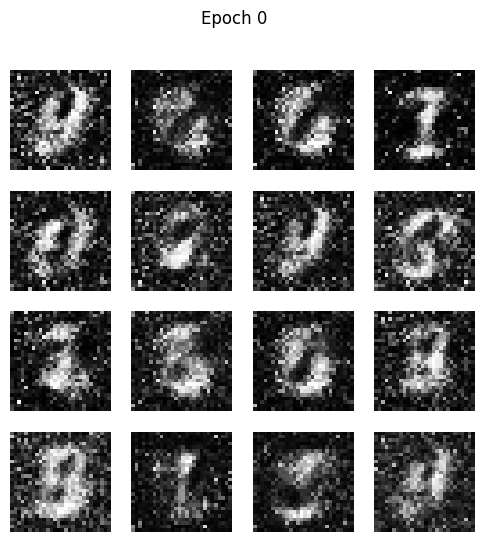


Starting epoch 1...
Epoch [1/50] Generator Loss: 2.1415 | Discriminator Loss: 0.7361

Starting epoch 2...
Epoch [2/50] Generator Loss: 2.5218 | Discriminator Loss: 0.5841

Starting epoch 3...
Epoch [3/50] Generator Loss: 2.8288 | Discriminator Loss: 0.4983

Starting epoch 4...
Epoch [4/50] Generator Loss: 2.9858 | Discriminator Loss: 0.4214

Starting epoch 5...
Epoch [5/50] Generator Loss: 2.9233 | Discriminator Loss: 0.4178


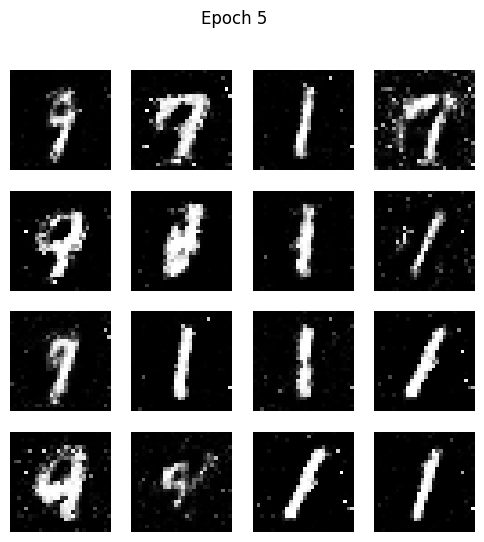


Starting epoch 6...
Epoch [6/50] Generator Loss: 2.7326 | Discriminator Loss: 0.4305

Starting epoch 7...
Epoch [7/50] Generator Loss: 2.5932 | Discriminator Loss: 0.4592

Starting epoch 8...
Epoch [8/50] Generator Loss: 2.4732 | Discriminator Loss: 0.5004

Starting epoch 9...
Epoch [9/50] Generator Loss: 2.4052 | Discriminator Loss: 0.5004

Starting epoch 10...
Epoch [10/50] Generator Loss: 2.3509 | Discriminator Loss: 0.5209


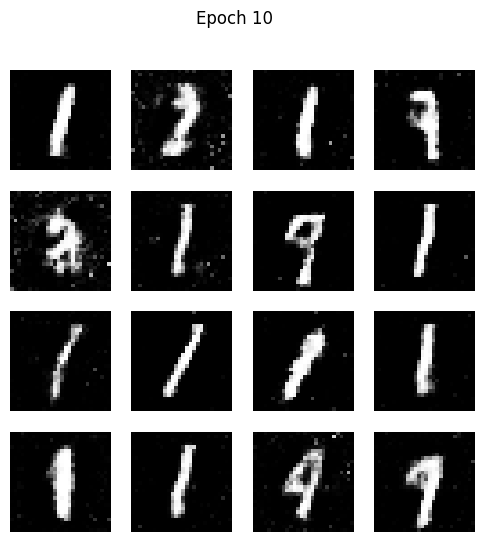


Starting epoch 11...
Epoch [11/50] Generator Loss: 2.2647 | Discriminator Loss: 0.5383

Starting epoch 12...
Epoch [12/50] Generator Loss: 2.2261 | Discriminator Loss: 0.5479

Starting epoch 13...
Epoch [13/50] Generator Loss: 2.1834 | Discriminator Loss: 0.5622

Starting epoch 14...
Epoch [14/50] Generator Loss: 2.1437 | Discriminator Loss: 0.5722

Starting epoch 15...
Epoch [15/50] Generator Loss: 2.1270 | Discriminator Loss: 0.5824


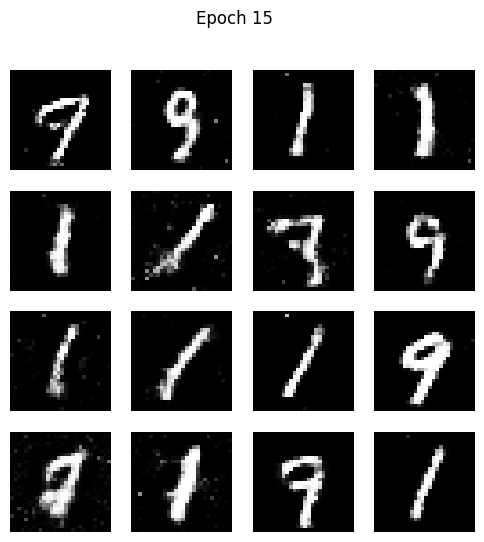


Starting epoch 16...
Epoch [16/50] Generator Loss: 2.1045 | Discriminator Loss: 0.5891

Starting epoch 17...
Epoch [17/50] Generator Loss: 2.0813 | Discriminator Loss: 0.5974

Starting epoch 18...
Epoch [18/50] Generator Loss: 2.0752 | Discriminator Loss: 0.5956

Starting epoch 19...
Epoch [19/50] Generator Loss: 2.0533 | Discriminator Loss: 0.6024

Starting epoch 20...
Epoch [20/50] Generator Loss: 2.0380 | Discriminator Loss: 0.6043


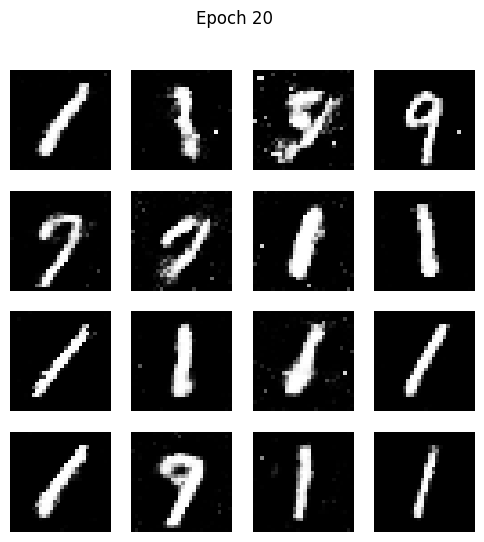


Starting epoch 21...
Epoch [21/50] Generator Loss: 2.0384 | Discriminator Loss: 0.6151

Starting epoch 22...
Epoch [22/50] Generator Loss: 2.0283 | Discriminator Loss: 0.6109

Starting epoch 23...
Epoch [23/50] Generator Loss: 2.0159 | Discriminator Loss: 0.6131

Starting epoch 24...
Epoch [24/50] Generator Loss: 1.9986 | Discriminator Loss: 0.6216

Starting epoch 25...
Epoch [25/50] Generator Loss: 1.9914 | Discriminator Loss: 0.6205


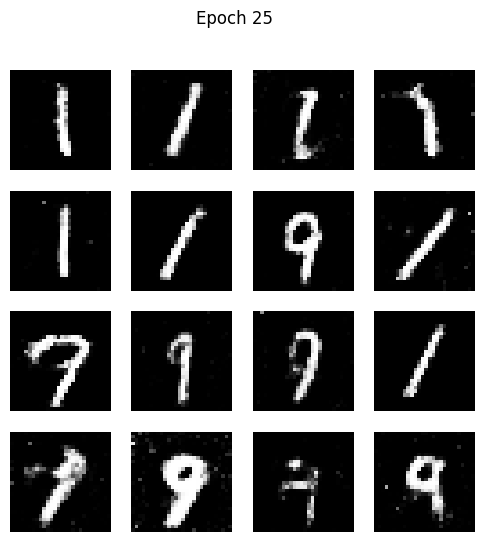


Starting epoch 26...
Epoch [26/50] Generator Loss: 1.9906 | Discriminator Loss: 0.6232

Starting epoch 27...
Epoch [27/50] Generator Loss: 1.9861 | Discriminator Loss: 0.6240

Starting epoch 28...
Epoch [28/50] Generator Loss: 1.9689 | Discriminator Loss: 0.6264

Starting epoch 29...
Epoch [29/50] Generator Loss: 1.9598 | Discriminator Loss: 0.6302

Starting epoch 30...
Epoch [30/50] Generator Loss: 1.9516 | Discriminator Loss: 0.6329


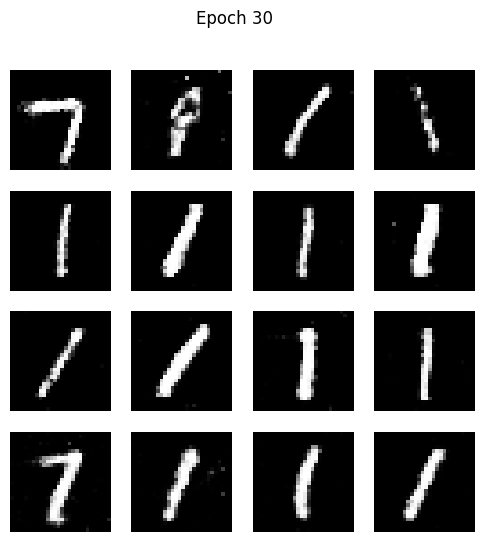


Starting epoch 31...
Epoch [31/50] Generator Loss: 1.9478 | Discriminator Loss: 0.6371

Starting epoch 32...
Epoch [32/50] Generator Loss: 1.9371 | Discriminator Loss: 0.6417

Starting epoch 33...
Epoch [33/50] Generator Loss: 1.9414 | Discriminator Loss: 0.6414

Starting epoch 34...
Epoch [34/50] Generator Loss: 1.9342 | Discriminator Loss: 0.6423

Starting epoch 35...
Epoch [35/50] Generator Loss: 1.9353 | Discriminator Loss: 0.6447


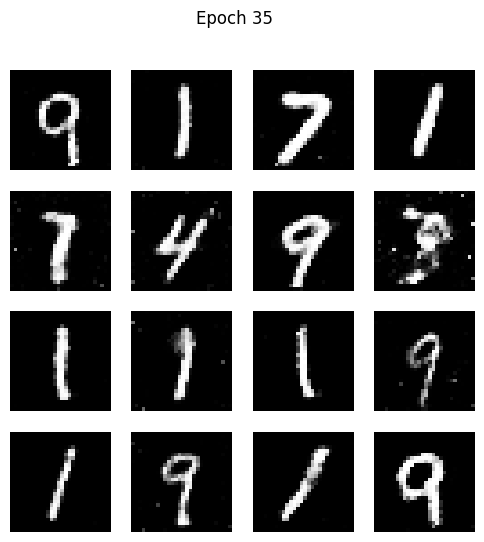


Starting epoch 36...
Epoch [36/50] Generator Loss: 1.9202 | Discriminator Loss: 0.6479

Starting epoch 37...
Epoch [37/50] Generator Loss: 1.9238 | Discriminator Loss: 0.6466

Starting epoch 38...
Epoch [38/50] Generator Loss: 1.9235 | Discriminator Loss: 0.6470

Starting epoch 39...
Epoch [39/50] Generator Loss: 1.9141 | Discriminator Loss: 0.6500

Starting epoch 40...
Epoch [40/50] Generator Loss: 1.9237 | Discriminator Loss: 0.6477


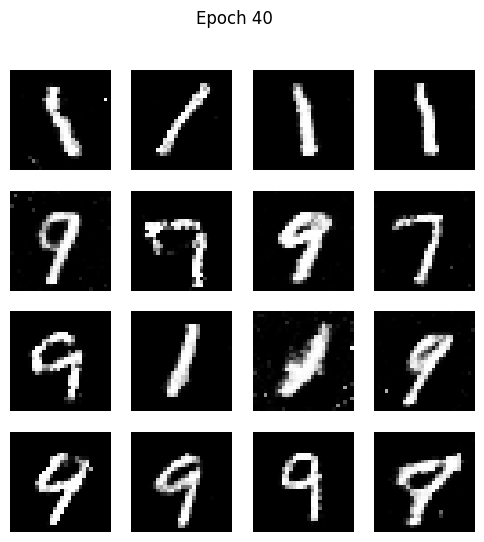


Starting epoch 41...
Epoch [41/50] Generator Loss: 1.9124 | Discriminator Loss: 0.6520

Starting epoch 42...
Epoch [42/50] Generator Loss: 1.9174 | Discriminator Loss: 0.6521

Starting epoch 43...
Epoch [43/50] Generator Loss: 1.9125 | Discriminator Loss: 0.6529

Starting epoch 44...
Epoch [44/50] Generator Loss: 1.9107 | Discriminator Loss: 0.6562

Starting epoch 45...
Epoch [45/50] Generator Loss: 1.9059 | Discriminator Loss: 0.6573


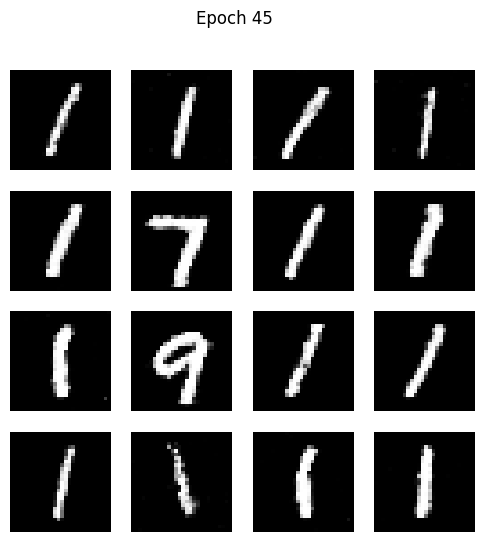


Starting epoch 46...
Epoch [46/50] Generator Loss: 1.9149 | Discriminator Loss: 0.6557

Starting epoch 47...
Epoch [47/50] Generator Loss: 1.9100 | Discriminator Loss: 0.6565

Starting epoch 48...
Epoch [48/50] Generator Loss: 1.9098 | Discriminator Loss: 0.6583

Starting epoch 49...
Epoch [49/50] Generator Loss: 1.9035 | Discriminator Loss: 0.6576
Training Finished!


In [ ]:
train_dcgan()